#Problem Statement:
Fashion MNIST is a dataset of Zalando's article images, consisting of 60,000 training examples and 10,000 test examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. The task is to classify these images into an apparel category amongst 10 categories on which the dataset is benchmarked.

#Objectives:

##Data Preparation and Visualization:

● Load the Fashion MNIST dataset.

● Visualize different samples from the dataset.

● Normalize the pixel values of the images to be between 0 and 1 for better model performance.

● Convert the output labels to categorical format for classification.

##Model Building and Training:

Construct a Neural Network using TensorFlow and Keras.

● The model should consist of multiple dense layers with a significant number of neurons.

● Utilize ReLU activation for hidden layers and softmax activation for the output layer.

● Train the model on the prepared dataset.

● Implement callbacks, particularly TensorBoard, to visualize the training process.

##Model Evaluation and Analysis:

● Evaluate the model's performance using a validation set.

● Analyze the training process with the help of TensorBoard.

● Save the trained model, including its architecture and learned weights.

##Model Loading and Verification:

● Load the saved model and verify its architecture.

● Check the consistency in the number of model parameters and weights



#Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import TensorBoard
import datetime
import os

#Load Dataset

In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Class names for the 10 categories
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot"
]

print(f"Training samples : {X_train.shape}")
print(f"Test samples     : {X_test.shape}")
print(f"Image shape      : {X_train.shape[1:]}")
print(f"Classes          : {class_names}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : (60000, 28, 28)
Test samples     : (10000, 28, 28)
Image shape      : (28, 28)
Classes          : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


#Visualize Sample Images

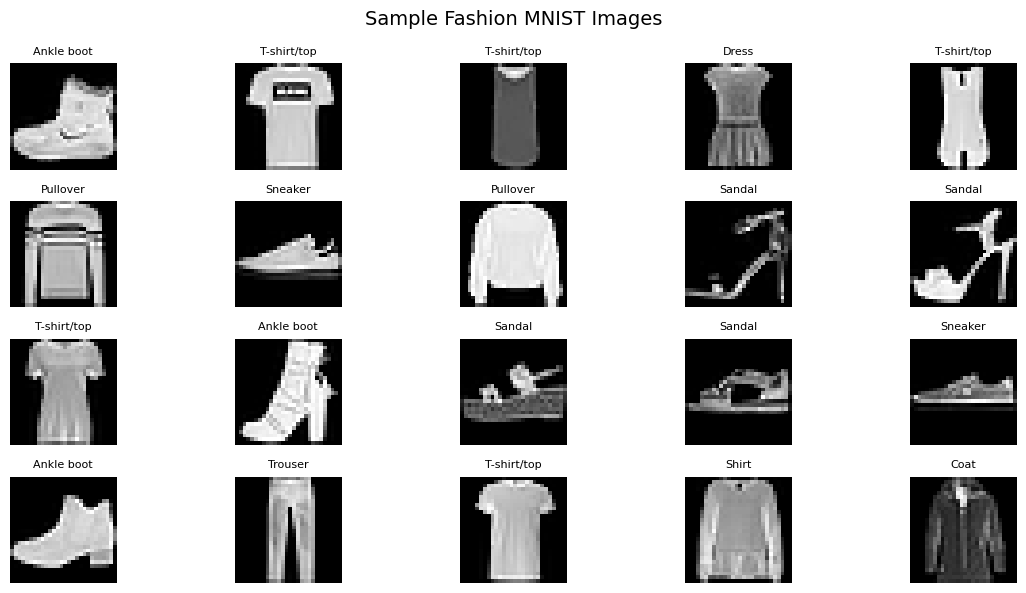

In [4]:
plt.figure(figsize=(12, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Sample Fashion MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
#Normalize Pixel Values (0–1)
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Flatten 28x28 → 784 for Dense layers
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f"X_train_flat shape : {X_train_flat.shape}")
print(f"y_train_cat shape  : {y_train_cat.shape}")

X_train_flat shape : (60000, 784)
y_train_cat shape  : (60000, 10)


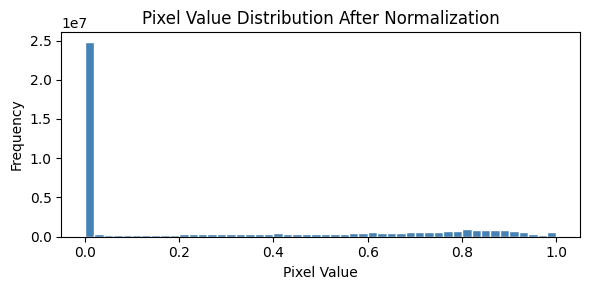

In [6]:
# Pixel value check after normalization

plt.figure(figsize=(6, 3))
plt.hist(X_train_flat.ravel(), bins=50, color="steelblue", edgecolor="white")
plt.title("Pixel Value Distribution After Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#Build the Neural Network

In [7]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),

        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),

        layers.Dense(10,  activation="softmax")   # output layer
    ], name="FashionMNIST_NN")
    return model

model = build_model()
model.summary()

Model: "FashionMNIST_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

#Compile the Model

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#TensorBoard Callback

In [9]:
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)

print(f"TensorBoard logs will be saved to: {log_dir}")

TensorBoard logs will be saved to: logs/fit/20260624-114841


#Train the Model

In [10]:
EPOCHS     = 20
BATCH_SIZE = 64

history = model.fit(
    X_train_flat, y_train_cat,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.15,          # 15 % of training data used for validation
    callbacks       = [tensorboard_cb],
    verbose         = 1
)

# Run this cell separately in Colab to open TensorBoard
# load_ext tensorboard
# tensorboard --logdir logs/fit

Epoch 1/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8176 - loss: 0.5021 - val_accuracy: 0.8552 - val_loss: 0.3984
Epoch 2/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8634 - loss: 0.3690 - val_accuracy: 0.8454 - val_loss: 0.4220
Epoch 3/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8754 - loss: 0.3335 - val_accuracy: 0.8727 - val_loss: 0.3554
Epoch 4/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8848 - loss: 0.3083 - val_accuracy: 0.8657 - val_loss: 0.3869
Epoch 5/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8930 - loss: 0.2889 - val_accuracy: 0.8802 - val_loss: 0.3336
Epoch 6/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8985 - loss: 0.2727 - val_accuracy: 0.8713 - val_loss: 0.3673
Epoch 7/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9018 - loss: 0.2625 - val_accuracy: 0.8808 - val_loss: 0.3383
Epoch 8/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9054 - loss: 0.2509 - val_accuracy: 0

#Plot Training History

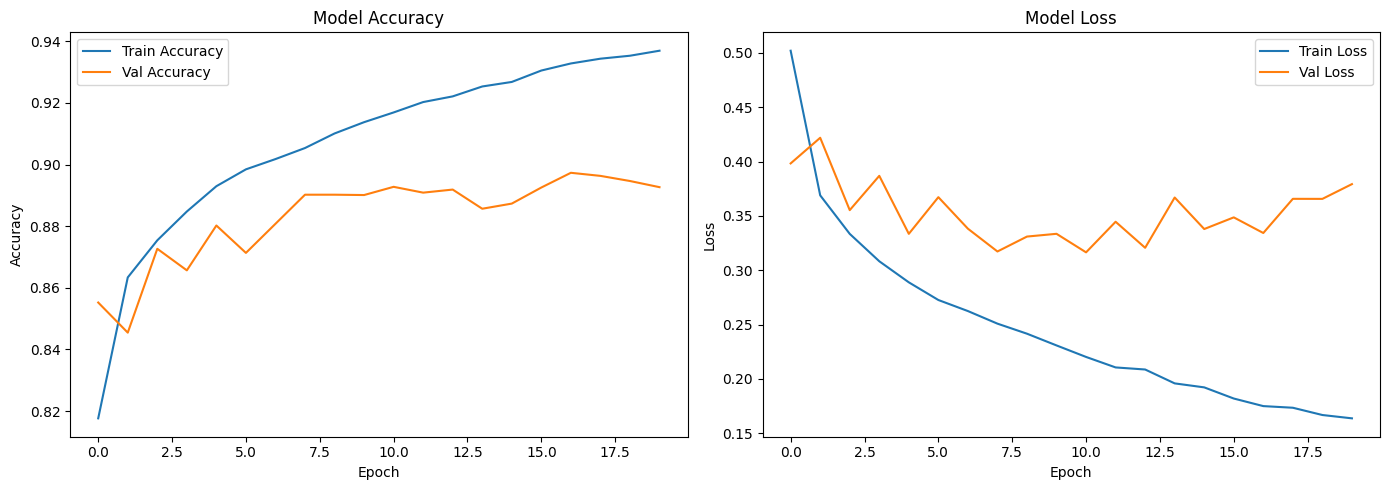

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#Evaluate on Test Set

In [12]:
test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f} %)")


Test Loss     : 0.4066
Test Accuracy : 0.8844  (88.44 %)


#Save the Model

In [13]:
MODEL_PATH = "fashion_mnist_model.keras"
model.save(MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")

Model saved to 'fashion_mnist_model.keras'


#Load the Model & Verify

In [14]:
loaded_model = keras.models.load_model(MODEL_PATH)
print("\n── Loaded Model Summary ──")
loaded_model.summary()


── Loaded Model Summary ──


Model: "FashionMNIST_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,725,152 (6.58 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,150,102 (4.39 MB)

In [15]:
# Compare parameter counts
orig_params   = model.count_params()
loaded_params = loaded_model.count_params()
print(f"\nOriginal model params : {orig_params:,}")
print(f"Loaded   model params : {loaded_params:,}")
print(f"Match                 : {orig_params == loaded_params}")

# Compare weights layer by layer
print("\n── Weight Consistency Check ──")
all_match = True
for orig_layer, load_layer in zip(model.layers, loaded_model.layers):
    for w_orig, w_load in zip(orig_layer.get_weights(), load_layer.get_weights()):
        if not np.allclose(w_orig, w_load):
            all_match = False
            print(f"  MISMATCH in layer: {orig_layer.name}")
            break

print("All weights match:", all_match)


Original model params : 575,050
Loaded   model params : 575,050
Match                 : True

── Weight Consistency Check ──
All weights match: True


#Predict & Visualise Results

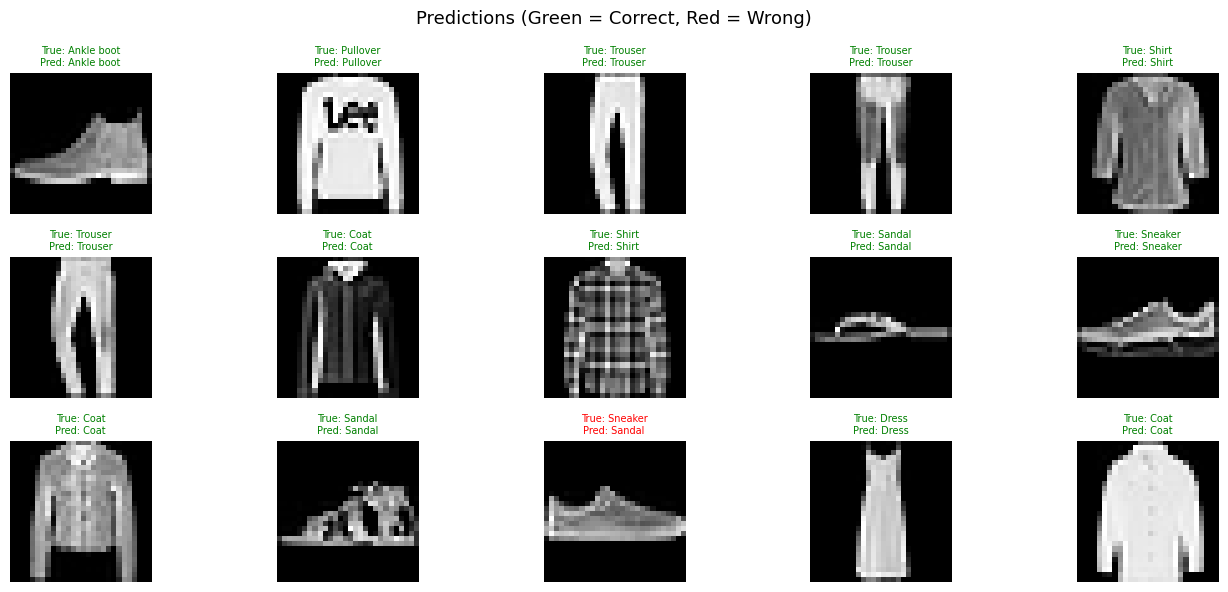

In [16]:
predictions = loaded_model.predict(X_test_flat, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(14, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    true_label = class_names[y_test[i]]
    pred_label = class_names[pred_labels[i]]
    color = "green" if pred_labels[i] == y_test[i] else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=7, color=color)
    plt.axis("off")

plt.suptitle("Predictions (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()